In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_excel("marketplace_liquidity_v5.xlsx")
df['date_created'] = pd.to_datetime(df['date_created'], format='%d/%m/%Y')
df['date_sold']    = pd.to_datetime(df['date_sold'],    format='%d/%m/%Y')

print(f"Total listings: {len(df)}")
print(f"Sold rate: {df['sold'].mean():.1%}")
print(f"Avg days to sell: {df['days_to_sell'].mean():.1f}")
df.head()

Total listings: 5000
Sold rate: 50.3%
Avg days to sell: 17.9


,listing_id,brand,model,model_year,condition,color,size_eu,original_retail_price,market_price,listing_price,price_gap_pct,city,seller_rating,seller_reviews,photos_count,date_created,date_sold,days_to_sell,season,sold
0,L00001,Nike,Pegasus 41,2025,Good,Blue,38,175,70,50,-0.286,Rome,3.7,44,9,2023-01-26,2023-02-08,13.0,Winter,1
1,L00002,ASICS,Magic Speed 4,2023,Good,White,42,110,40,35,-0.125,Milan,4.3,14,4,2023-02-02,2023-02-20,18.0,Winter,1
2,L00003,Adidas,Supernova Rise,2020,Good,Black,37,135,55,85,0.545,Madrid,4.8,17,8,2023-08-14,2023-09-07,24.0,Summer,1
3,L00004,On Running,Cloudsurfer,2023,New with tags,Pink,39,190,160,160,0.000,Hamburg,3.6,48,5,2023-08-09,NaT,NaN,Summer,0
4,L00005,Hoka,Clifton 9,2022,New with tags,White,40,155,140,180,0.286,Turin,4.1,10,4,2024-04-15,NaT,NaN,Spring,0


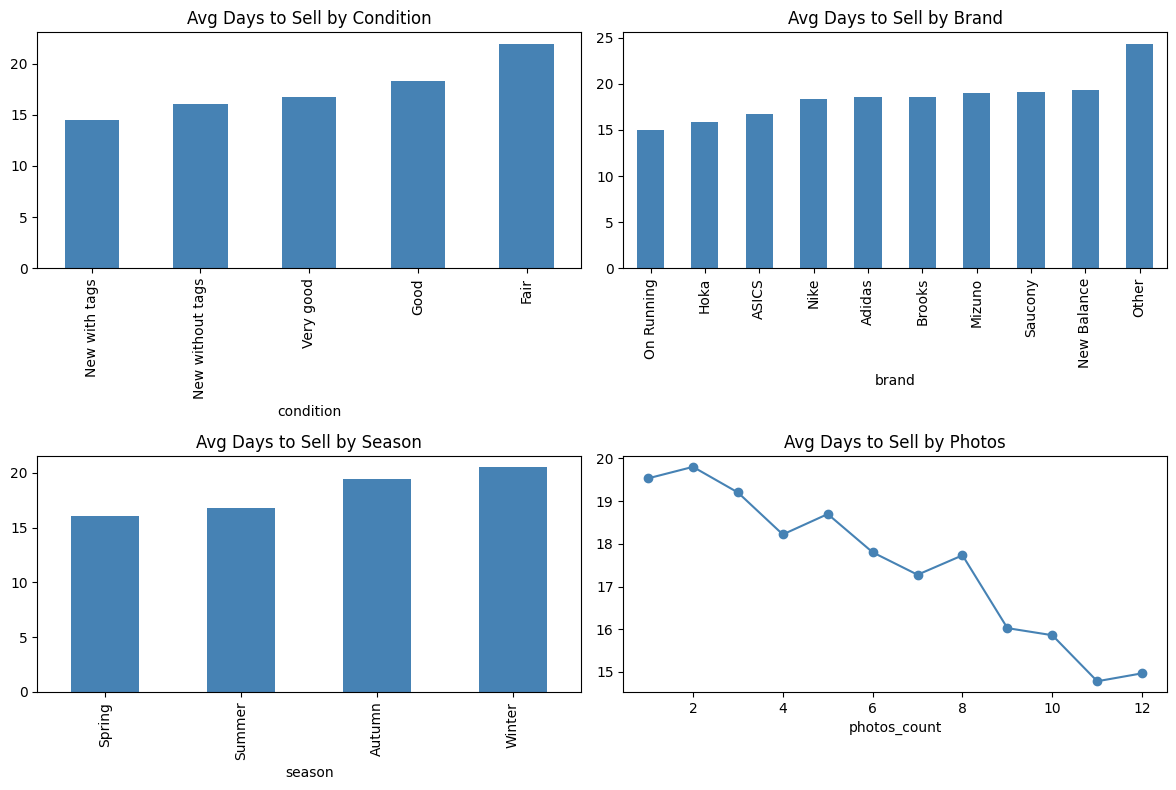

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.groupby('condition')['days_to_sell'].mean().sort_values().plot(
    kind='bar', ax=axes[0,0], title='Avg Days to Sell by Condition', color='steelblue')

df.groupby('brand')['days_to_sell'].mean().sort_values().plot(
    kind='bar', ax=axes[0,1], title='Avg Days to Sell by Brand', color='steelblue')

df.groupby('season')['days_to_sell'].mean().sort_values().plot(
    kind='bar', ax=axes[1,0], title='Avg Days to Sell by Season', color='steelblue')

df.groupby('photos_count')['days_to_sell'].mean().sort_index().plot(
    ax=axes[1,1], title='Avg Days to Sell by Photos', color='steelblue', marker='o')

plt.tight_layout()
plt.savefig('eda_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

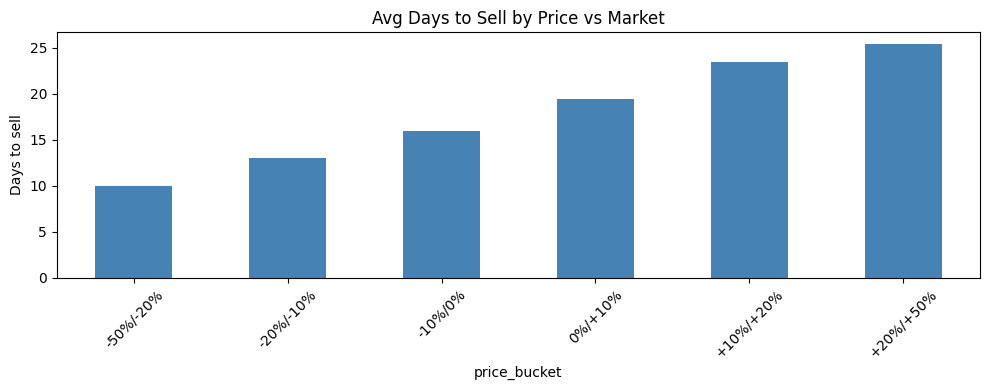

In [4]:
sold_df = df[df['sold'] == 1].copy()
sold_df['price_bucket'] = pd.cut(sold_df['price_gap_pct'],
    bins=[-0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5],
    labels=['-50%/-20%', '-20%/-10%', '-10%/0%', '0%/+10%', '+10%/+20%', '+20%/+50%'])

sold_df.groupby('price_bucket')['days_to_sell'].mean().plot(
    kind='bar', figsize=(10, 4), title='Avg Days to Sell by Price vs Market',
    color='steelblue')
plt.ylabel('Days to sell')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_price_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
model_df = df[df['sold'] == 1].copy()
model_df = model_df.drop(columns=[
    'listing_id', 'date_created', 'date_sold', 'sold',
    'listing_price', 'original_retail_price', 'market_price'
])
model_df = pd.get_dummies(model_df, columns=['brand', 'model', 'condition', 'color', 'city', 'season'])

X = model_df.drop(columns=['days_to_sell'])
y = model_df['days_to_sell']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2012, 86) | Test: (503, 86)


In [13]:
rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²:  {r2:.3f}")
print(f"MAE: {mae:.1f} days")

R²:  0.783
MAE: 2.7 days


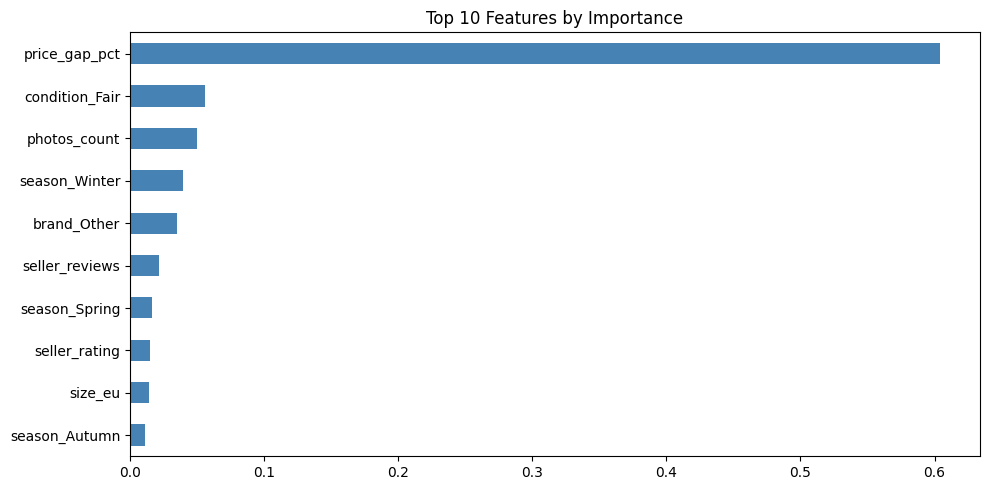

price_gap_pct     0.604
condition_Fair    0.056
photos_count      0.050
season_Winter     0.040
brand_Other       0.035
seller_reviews    0.022
season_Spring     0.017
seller_rating     0.015
size_eu           0.014
season_Autumn     0.011
dtype: float64


In [14]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

top10.sort_values().plot(kind='barh', figsize=(10, 5),
    title='Top 10 Features by Importance', color='steelblue')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top10.round(3))

In [8]:
joblib.dump(rf, 'liquidity_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Model saved.")

Model saved.


In [15]:
joblib.dump(rf, 'liquidity_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Model saved.")

Model saved.
